In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

b = np.load('rmd17_aspirin.npz')
print(b['nuclear_charges'])

[6 6 6 6 6 6 6 8 8 8 6 6 8 1 1 1 1 1 1 1 1]


In [ ]:
all_coords = b['coords']
all_energies = b['energies']

print(all_coords.shape)
print(all_energies.shape)

N = len(all_coords)
 
perm = np.random.permutation(N)

coords = all_coords[perm[:2000]]        
energies = all_energies[perm[:2000]]

print(coords.shape)
print(energies.shape)


(100000, 21, 3)
(100000,)
(2000, 21, 3)
(2000,)


In [3]:
bonds = [(0, 2), (2, 3), (3, 1), (1, 6), (6, 5), (5, 0), (5, 10), (7, 10), (9, 10), (9, 13), (6, 12), (11, 12), (8, 11),   
(4, 11), (4, 18), (4, 19), (4, 20), (0, 14), (1, 15), (2, 16), (3, 17)]

def bond_lengths(coords):
    lengths = []
    for i in range(len(coords)):
        for a,b in bonds:
            length = np.linalg.norm(coords[i,a,:]-coords[i,b,:])

            lengths.append(length)
    return(lengths)

ben_lengths = np.array(bond_lengths(coords))
BL = ben_lengths.reshape(len(coords), len(bonds))
print(BL)
print(BL.shape)

[[1.43410062 1.43751805 1.40804134 ... 1.11082531 1.06532875 1.10077643]
 [1.46145528 1.42242147 1.39913742 ... 1.10862287 1.04924066 1.1243054 ]
 [1.47395896 1.35725458 1.41800627 ... 1.11625938 1.11898328 1.1237611 ]
 ...
 [1.47775705 1.39254694 1.34594275 ... 1.10959697 1.09511972 1.08693672]
 [1.39433181 1.4322044  1.35637897 ... 1.12441558 1.14579408 1.09434118]
 [1.42714063 1.44496661 1.42721896 ... 1.11287277 1.10357665 1.1080635 ]]
(2000, 21)


In [4]:
angles = [(5, 0, 2), (0, 2, 3), (2, 3, 1), (3, 1, 6), (1, 6, 5), (6, 5, 0), (5, 0, 14), (2, 0, 14), (6, 1, 15), 
(3, 1, 15), (0, 2, 16), (3, 2, 16), (2, 3, 17), (1, 3, 17), (0, 5, 10), (6, 5, 10), (5, 10, 7), (5, 10, 9), (7, 10, 9),  
(10, 9, 13), (1, 6, 12), (5, 6, 12), (6, 12, 11), (12, 11, 8), (12, 11, 4), (8, 11, 4), (11, 4, 18), (11, 4, 19), 
(11, 4, 20), (18, 4, 19), (18, 4, 20), (19, 4, 20)]  


def bond_angles(coords):
    ben_angles = []
    for o in range(len(coords)):
        for i,j,k in angles:
            length1 = np.linalg.norm(coords[o,i,:]-coords[o,j,:])
            length2 = np.linalg.norm(coords[o,k,:]-coords[o,j,:])


            dot_prod = np.dot((coords[o,i,:]-coords[o,j,:]),(coords[o,k,:]-coords[o,j,:]))


            cosang = dot_prod / (length1 * length2)


            ben_angles.append(np.acos(cosang))
    return(ben_angles)


benz_angles = np.array(bond_angles(coords))
AN = benz_angles.reshape(len(coords), len(angles))
print(AN)
print(AN.shape)

[[2.07112424 2.08954024 2.12184551 ... 2.05662617 1.80673384 2.00891199]
 [2.13437259 1.99705893 2.09404633 ... 1.76607741 2.02988299 1.8552233 ]
 [2.17384589 2.04113925 2.12018992 ... 1.90251307 1.92082296 1.87191631]
 ...
 [2.17390565 1.94807883 2.17777459 ... 1.9007694  1.97222539 1.75213853]
 [2.11205332 2.12716753 2.04171963 ... 2.02364287 1.87399602 1.93157764]
 [2.06621509 2.04931302 2.09121985 ... 2.07674852 1.76653176 2.04731471]]
(2000, 32)


In [5]:
X = np.concatenate((BL,AN), axis=1)
y = np.array(energies)


print(X)
print(y)
print(X.shape)
print(y.shape)

[[1.43410062 1.43751805 1.40804134 ... 2.05662617 1.80673384 2.00891199]
 [1.46145528 1.42242147 1.39913742 ... 1.76607741 2.02988299 1.8552233 ]
 [1.47395896 1.35725458 1.41800627 ... 1.90251307 1.92082296 1.87191631]
 ...
 [1.47775705 1.39254694 1.34594275 ... 1.9007694  1.97222539 1.75213853]
 [1.39433181 1.4322044  1.35637897 ... 2.02364287 1.87399602 1.93157764]
 [1.42714063 1.44496661 1.42721896 ... 2.07674852 1.76653176 2.04731471]]
[-406280.61687373 -406275.35217995 -406277.63107252 ... -406263.79108645
 -406283.29522054 -406275.68177441]
(2000, 53)
(2000,)


In [6]:
mu_X = X.mean(axis=0)
std_X = X.std(axis=0)

X_new = (X - mu_X)/ std_X

mu_y = y.mean()
std_y = y.std()

y_new = (y - mu_y)/ std_y

print(y_new)

[-1.03556389 -0.18910498 -0.55550595 ...  1.6696908  -1.46618923
 -0.24209727]


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_new, y_new, test_size=0.2)

X_train_t = torch.FloatTensor(X_train)
X_test_t = torch.FloatTensor(X_test)

y_train_t = torch.FloatTensor(y_train).unsqueeze(1)
y_test_t = torch.FloatTensor(y_test).unsqueeze(1)

print(y_train_t.shape)

torch.Size([1600, 1])


In [8]:
class Model(nn.Module):
    
    def __init__(self, input_features = 53, hidden1 = 64, hidden2 = 32, hidden3 = 16, output_features = 1):
        super().__init__()
        self.fc1 = nn.Linear(input_features, hidden1) 
        self.fc2 = nn.Linear(hidden1, hidden2) 
        self.fc3 = nn.Linear(hidden2, hidden3) 
        self.fc4 = nn.Linear(hidden3, output_features)
        self.ac1 = nn.SiLU()
        self.ac2 = nn.SiLU()
        self.ac3 = nn.SiLU()

    def forward(self, x):
        x = self.fc1(x) 
        x = self.ac1(x)
        x = self.fc2(x)
        x = self.ac2(x) 
        x = self.fc3(x)
        x = self.ac3(x)
        x = self.fc4(x) 
        return x

In [9]:
epochs = 1000
losses = []

torch.manual_seed(42)
model = Model()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4, weight_decay = 1e-3)

for epoch in range(epochs):

    model.train()

    y_pred = model(X_train_t) 
    loss = criterion(y_pred, y_train_t)    
    losses.append(loss.item()) 


    if epoch%10==0:
        print(f'Epoch: {epoch} and loss: {loss}') 

    optimizer.zero_grad() 
    loss.backward() 
    optimizer.step() 

Epoch: 0 and loss: 1.053166151046753
Epoch: 10 and loss: 1.0433335304260254
Epoch: 20 and loss: 1.034203290939331
Epoch: 30 and loss: 1.0250756740570068
Epoch: 40 and loss: 1.0151185989379883
Epoch: 50 and loss: 1.0035001039505005
Epoch: 60 and loss: 0.989398181438446
Epoch: 70 and loss: 0.9720882177352905
Epoch: 80 and loss: 0.9510782361030579
Epoch: 90 and loss: 0.9261063933372498
Epoch: 100 and loss: 0.896897554397583
Epoch: 110 and loss: 0.8631079196929932
Epoch: 120 and loss: 0.824672520160675
Epoch: 130 and loss: 0.7820376753807068
Epoch: 140 and loss: 0.7359641790390015
Epoch: 150 and loss: 0.6867063641548157
Epoch: 160 and loss: 0.6338474154472351
Epoch: 170 and loss: 0.5778037309646606
Epoch: 180 and loss: 0.5204321146011353
Epoch: 190 and loss: 0.46438589692115784
Epoch: 200 and loss: 0.41219985485076904
Epoch: 210 and loss: 0.3655311167240143
Epoch: 220 and loss: 0.3249666094779968
Epoch: 230 and loss: 0.2903282046318054
Epoch: 240 and loss: 0.2609940767288208
Epoch: 250 and

C:\Users\home\AppData\Local\Temp\ipykernel_21420\328958661.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


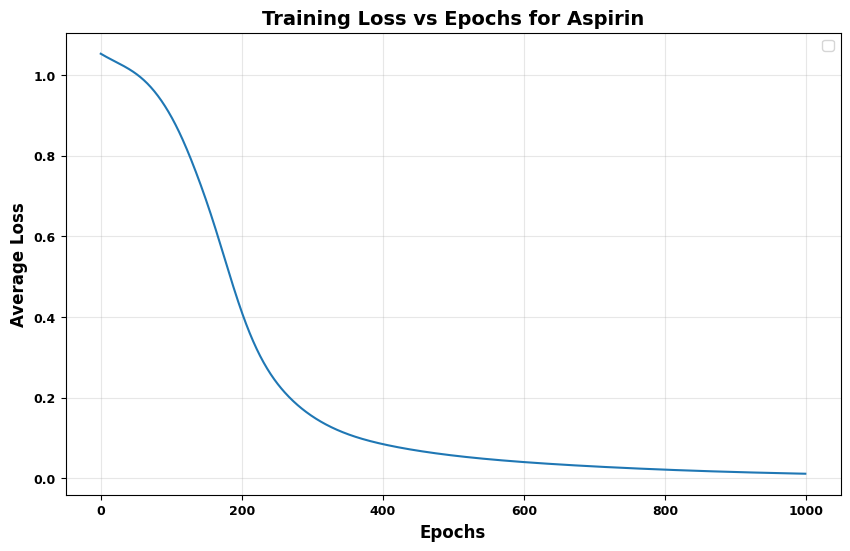

In [10]:
plt.figure(figsize=(10, 6))
plt.plot(range(epochs), losses)
plt.xlabel('Epochs', fontsize=12, fontweight='bold')
plt.ylabel('Average Loss', fontsize=12, fontweight='bold')
plt.xticks(fontsize=9, fontweight='bold')
plt.yticks(fontsize=9, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
#plt.savefig('NNTrain_loss_vs_epoch_aspirin.png')
plt.title('Training Loss vs Epochs for Aspirin', fontsize=14, fontweight='bold')
plt.show()

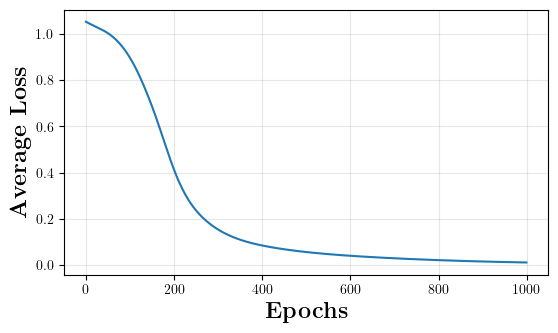

In [ ]:
import matplotlib as mpl

mpl.rcParams.update({"text.usetex": True, "font.family": "serif", "font.serif": ["Computer Modern"], "axes.labelsize": 17,
    "font.size": 17, "legend.fontsize": 13, "xtick.labelsize": 13, "ytick.labelsize": 13})

def set_size(width_pt, fraction=1):
    inches_per_pt = 1/72.27
    golden_ratio = (5**0.5 - 1)/2
    width_in = width_pt * inches_per_pt * fraction
    height_in = width_in * golden_ratio
    return (width_in, height_in)

fig = plt.figure(figsize=set_size(426))

plt.plot(losses, label='Training Loss')
plt.xlabel(r'\textbf{Epochs}')
plt.ylabel(r'\textbf{Average Loss}')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig('NN_Aspirin_Loss.pdf')
plt.show()

In [12]:
model.eval()
with torch.no_grad():
    final_test_pred = model(X_test_t)
    final_test_loss = nn.MSELoss()
    loss = final_test_loss(final_test_pred, y_test_t)
print("final test loss:", float(loss))

pred_unnormalized = final_test_pred.numpy().squeeze() * std_y + mu_y
true_unnormalized = y_test_t.numpy().squeeze() * std_y + mu_y

final test loss: 0.4468314051628113


In [13]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score(true_unnormalized, pred_unnormalized)
mae = mean_absolute_error(true_unnormalized, pred_unnormalized)
mse = mean_squared_error(true_unnormalized, pred_unnormalized)
rmse = np.sqrt(mse)

print(f"R² Score: {r2:.4f}")  
print(f"MAE: {mae:.4f}")      
print(f"RMSE: {rmse:.4f}")

R² Score: 0.5414
MAE: 3.2952
RMSE: 4.1576


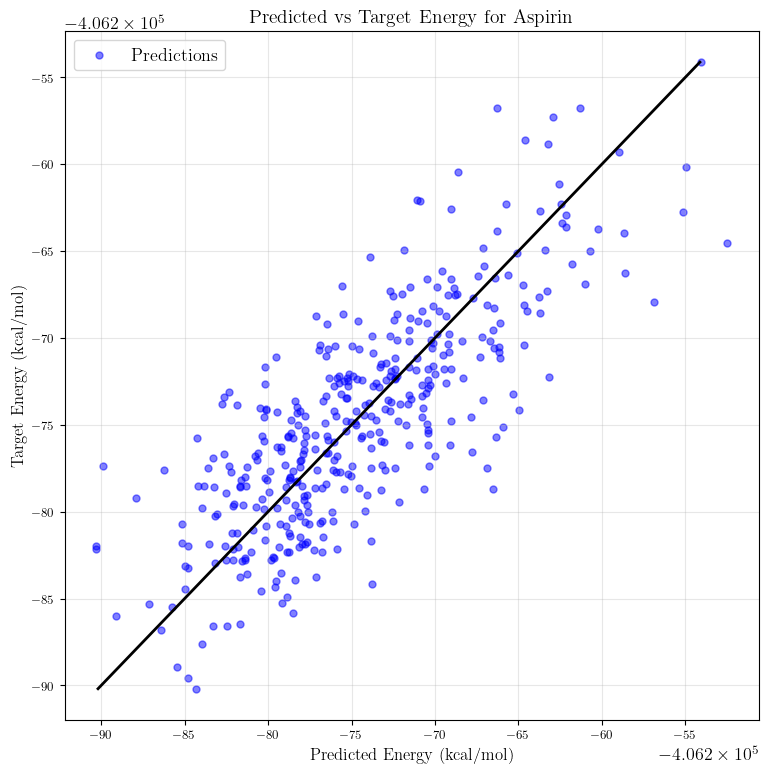

In [ ]:
plt.figure(figsize=(8,8))
plt.scatter(pred_unnormalized, true_unnormalized, alpha=0.5, s=25, color='blue', label='Predictions')
plt.plot([true_unnormalized.min(), true_unnormalized.max()], [true_unnormalized.min(), true_unnormalized.max()], 'k-', lw=2)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlabel('Predicted Energy (kcal/mol)', fontsize=12, fontweight='bold')
plt.ylabel('Target Energy (kcal/mol)', fontsize=12, fontweight='bold')
plt.xticks(fontsize=9, fontweight='bold')
plt.yticks(fontsize=9, fontweight='bold')
plt.tight_layout()
#plt.savefig('NNNtarget_vs_predE_aspirin.png')
plt.title('Predicted vs Target Energy for Aspirin', fontsize=14, fontweight='bold')
plt.show()


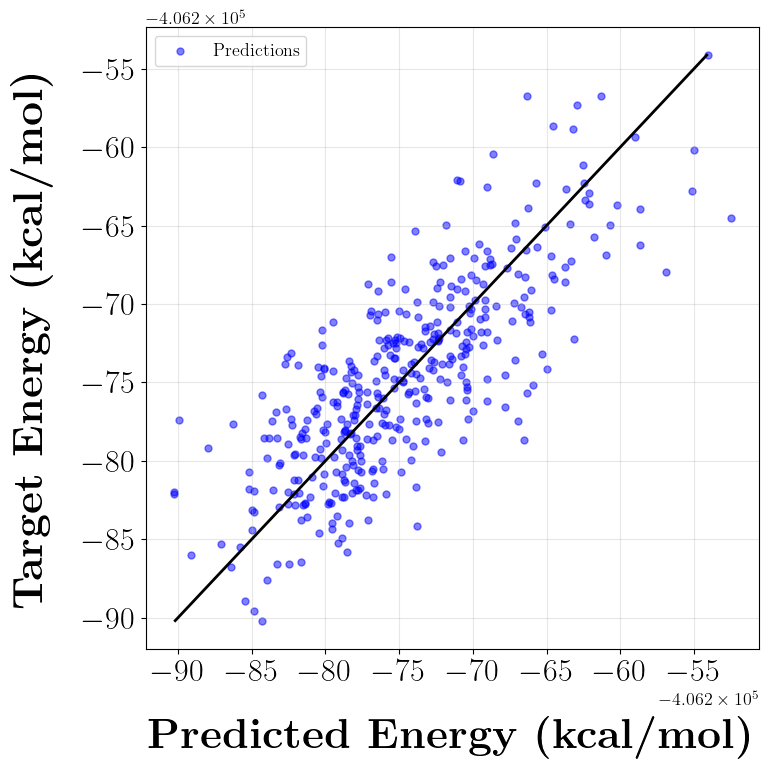

: 

In [ ]:
plt.figure(figsize=(8,8))
plt.scatter(pred_unnormalized, true_unnormalized, alpha=0.5, s=25, color='blue', label='Predictions')
plt.plot([true_unnormalized.min(), true_unnormalized.max()], [true_unnormalized.min(), true_unnormalized.max()],'k-', lw=2)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlabel(r'\textbf{Predicted Energy (kcal/mol)}', fontsize=31, labelpad=21)
plt.ylabel(r'\textbf{Target Energy (kcal/mol)}', fontsize=31, labelpad=21)
plt.xticks(fontsize=23)
plt.yticks(fontsize=23)
plt.tight_layout()
#plt.savefig('NN_Aspirin_Scatter.pdf', bbox_inches='tight')
plt.show()